In [1]:
from logging import getLogger
from itertools import product
from utils.dataset import RecDataset
from utils.dataloader import TrainDataLoader, EvalDataLoader
from utils.logger import init_logger
from utils.configurator import Config
from utils.utils import init_seed, get_model, get_trainer, dict2str
import platform
import os

In [2]:
model = 'PGL'
dataset = 'baby'
config_dict = {
    'gpu_id': 0,
}
save_model = True
mg = False

In [3]:
config = Config(model, dataset, config_dict, mg)
init_logger(config)
logger = getLogger()
# print config infor
logger.info('██Server: \t' + platform.node())
logger.info('██Dir: \t' + os.getcwd() + '\n')
logger.info(config)

# load data
dataset = RecDataset(config)
# print dataset statistics
logger.info(str(dataset))

train_dataset, valid_dataset, test_dataset = dataset.split()
logger.info('\n====Training====\n' + str(train_dataset))
logger.info('\n====Validation====\n' + str(valid_dataset))
logger.info('\n====Testing====\n' + str(test_dataset))

18 Dec 11:42    INFO ██Server: 	HTCW11
18 Dec 11:42    INFO ██Dir: 	d:\Show_me_everything\Amazon-Recommend-System\src

18 Dec 11:42    INFO 
gpu_id=0
use_gpu=True
seed=[999]
data_path=../data/
inter_splitting_label=x_label
filter_out_cod_start_users=True
is_multimodal_model=True
checkpoint_dir=saved
save_recommended_topk=True
recommend_topk=recommend_topk/
embedding_size=64
weight_decay=0.0
req_training=True
epochs=1000
stopping_step=20
train_batch_size=2048
learner=adam
learning_rate=0.001
learning_rate_scheduler=[0.96, 50]
eval_step=1
training_neg_sample_num=1
use_neg_sampling=True
use_full_sampling=False
NEG_PREFIX=neg__
USER_ID_FIELD=userID
ITEM_ID_FIELD=itemID
TIME_FIELD=timestamp
field_separator=	
metrics=['Recall', 'NDCG', 'Precision', 'MAP']
topk=[5, 10, 20, 50]
valid_metric=Recall@20
eval_batch_size=4096
use_raw_features=False
max_txt_len=32
max_img_size=256
vocab_size=30522
type_vocab_size=2
hidden_size=4
pad_token_id=0
max_position_embeddings=512
layer_norm_eps=1e-12
hidden_

In [4]:
train_data = TrainDataLoader(config, train_dataset, batch_size=config['train_batch_size'], shuffle=True)
(valid_data, test_data) = (
    EvalDataLoader(config, valid_dataset, additional_dataset=train_dataset, batch_size=config['eval_batch_size']),
    EvalDataLoader(config, test_dataset, additional_dataset=train_dataset, batch_size=config['eval_batch_size']))

In [5]:
hyper_ret = []
val_metric = config['valid_metric'].lower()
best_test_value = 0.0
idx = best_test_idx = 0
hyper_ls = []
if "seed" not in config['hyper_parameters']:
    config['hyper_parameters'] = ['seed'] + config['hyper_parameters']
for i in config['hyper_parameters']:
    hyper_ls.append(config[i] or [None])
# combinations
combinators = list(product(*hyper_ls))
total_loops = len(combinators)

In [6]:
for i in combinators:
    print(i)

(999, 0.2, 0, 'local')


In [7]:
for j, k in zip(config['hyper_parameters'], combinators[0]):
    config[j] = k
init_seed(config['seed'])

logger.info('========={}/{}: Parameters:{}={}======='.format(
    idx+1, total_loops, config['hyper_parameters'], combinators[0]))

# set random state of dataloader
train_data.pretrain_setup()
# model loading and initialization
model = get_model(config['model'])(config, train_data).to(config['device'])
logger.info(model)

# trainer loading and initialization
trainer = get_trainer()(config, model, mg)

18 Dec 11:42    INFO =========1/1: Parameters:['seed', 'dropout', 'reg_weight', 'mode']=(999, 0.2, 0, 'local')=======
d:\Show_me_everything\Amazon-Recommend-System\src\models\pgl.py:136: UserWarning: torch.sparse.SparseTensor(indices, values, shape, *, device=) is deprecated.  Please use torch.sparse_coo_tensor(indices, values, shape, dtype=, device=). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:656.)
  return torch.sparse.FloatTensor(i, data, torch.Size((self.n_nodes, self.n_nodes)))
18 Dec 11:42    INFO PGL(
  (user_text): Embedding(19445, 64)
  (user_image): Embedding(19445, 64)
  (image_embedding): Embedding(7050, 4096)
  (image_trs): Linear(in_features=4096, out_features=64, bias=True)
  (text_embedding): Embedding(7050, 384)
  (text_trs): Linear(in_features=384, out_features=64, bias=True)
  (dropoutf): Dropout(p=0.2, inplace=False)
)
Trainable parameters: 34359808


In [8]:
best_valid_score, best_valid_result, best_test_upon_valid = trainer.fit(train_data, valid_data=valid_data, test_data=test_data, saved=save_model)


18 Dec 11:42    INFO epoch 0 training [time: 5.88s, train loss: 36.9708]
18 Dec 11:42    INFO epoch 0 evaluating [time: 3.39s, valid_score: 0.051400]
18 Dec 11:42    INFO valid result: 
recall@5: 0.0213    recall@10: 0.0339    recall@20: 0.0514    recall@50: 0.0906    ndcg@5: 0.0142    ndcg@10: 0.0183    ndcg@20: 0.0228    ndcg@50: 0.0306    precision@5: 0.0045    precision@10: 0.0036    precision@20: 0.0027    precision@50: 0.0019    map@5: 0.0117    map@10: 0.0133    map@20: 0.0146    map@50: 0.0158    
18 Dec 11:42    INFO test result: 
recall@5: 0.0193    recall@10: 0.0332    recall@20: 0.0525    recall@50: 0.0882    ndcg@5: 0.0131    ndcg@10: 0.0176    ndcg@20: 0.0226    ndcg@50: 0.0298    precision@5: 0.0044    precision@10: 0.0037    precision@20: 0.0029    precision@50: 0.0020    map@5: 0.0106    map@10: 0.0124    map@20: 0.0137    map@50: 0.0149    
18 Dec 11:42    INFO ██ PGL--Best validation results updated!!!
18 Dec 11:43    INFO epoch 1 training [time: 5.23s, train loss: 3

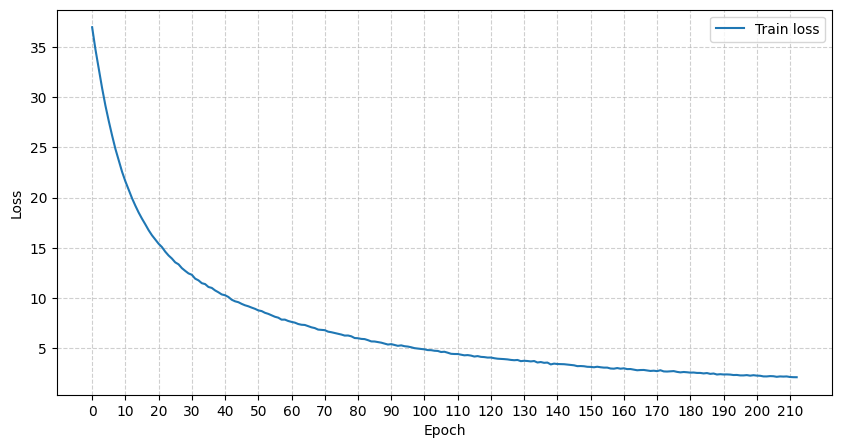

<Figure size 640x480 with 0 Axes>

In [9]:
trainer.plot_train_loss(figsize=(10,5), markersize=0)

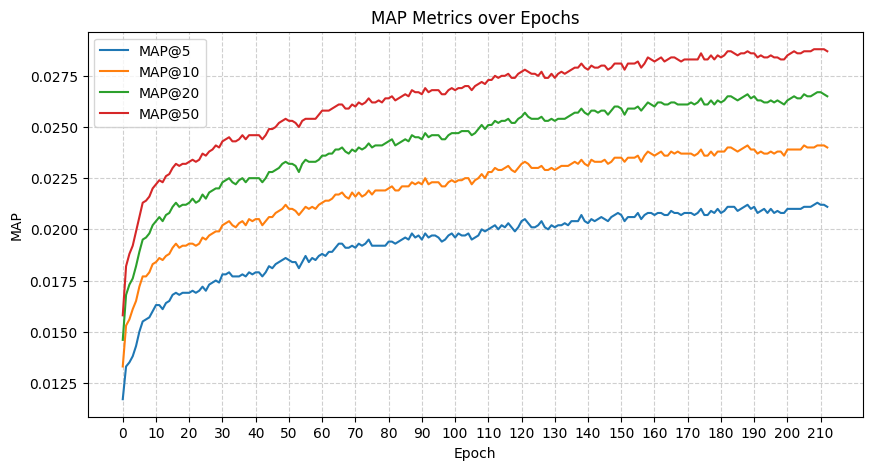

In [10]:
trainer.plot_map(figsize=(10,5), markersize=0)

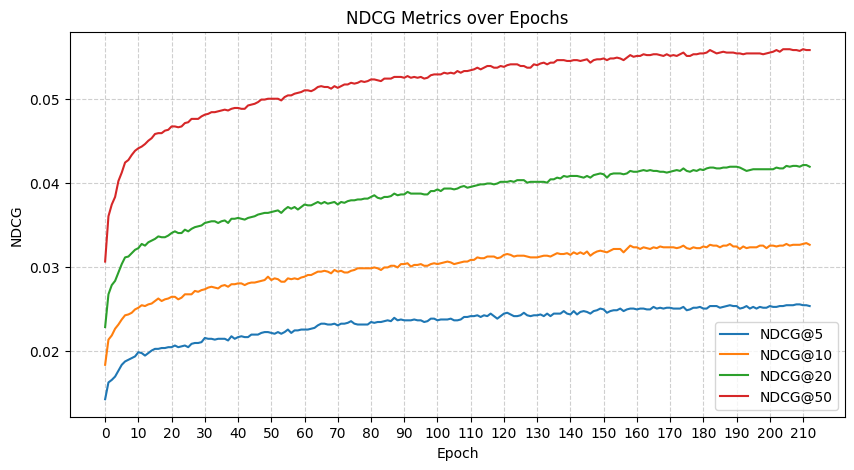

In [11]:
trainer.plot_ndcg(figsize=(10,5), markersize=0)

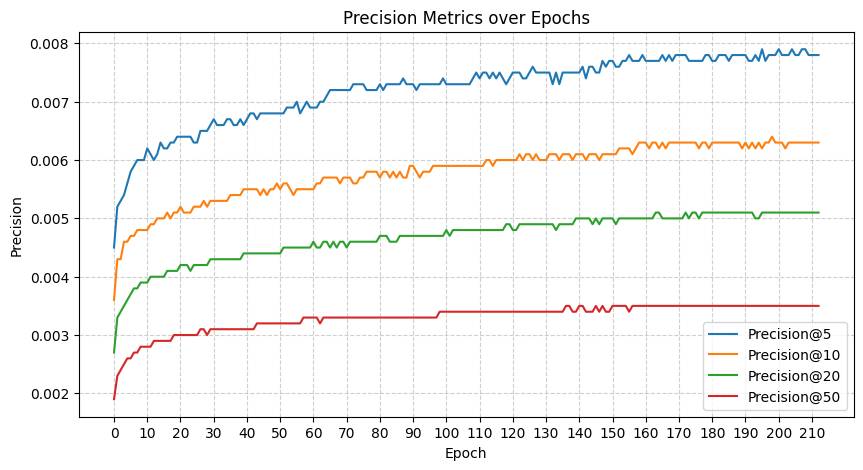

In [12]:
trainer.plot_precision(figsize=(10,5), markersize=0)

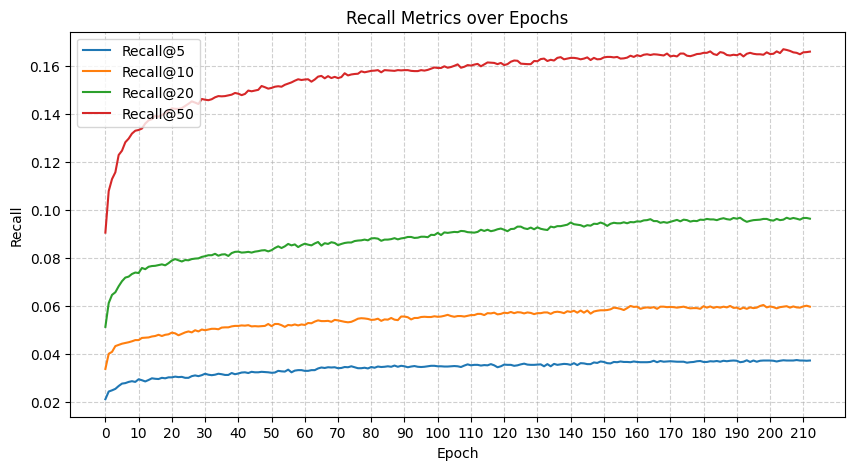

In [13]:
trainer.plot_recall(figsize=(10,5), markersize=0)

In [14]:
hyper_ret.append((combinators[0], best_valid_result, best_test_upon_valid))

# save best test
if best_test_upon_valid[val_metric] > best_test_value:
    best_test_value = best_test_upon_valid[val_metric]
    best_test_idx = idx
idx += 1

logger.info('best valid result: {}'.format(dict2str(best_valid_result)))
logger.info('test result: {}'.format(dict2str(best_test_upon_valid)))
logger.info('████Current BEST████:\nParameters: {}={},\n'
            'Valid: {},\nTest: {}\n\n\n'.format(config['hyper_parameters'],
    hyper_ret[best_test_idx][0], dict2str(hyper_ret[best_test_idx][1]), dict2str(hyper_ret[best_test_idx][2])))


18 Dec 12:24    INFO best valid result: recall@5: 0.0367    recall@10: 0.0588    recall@20: 0.0968    recall@50: 0.1650    ndcg@5: 0.0250    ndcg@10: 0.0321    ndcg@20: 0.0418    ndcg@50: 0.0554    precision@5: 0.0077    precision@10: 0.0062    precision@20: 0.0051    precision@50: 0.0035    map@5: 0.0208    map@10: 0.0237    map@20: 0.0263    map@50: 0.0284    
18 Dec 12:24    INFO test result: recall@5: 0.0383    recall@10: 0.0614    recall@20: 0.0982    recall@50: 0.1670    ndcg@5: 0.0254    ndcg@10: 0.0330    ndcg@20: 0.0424    ndcg@50: 0.0563    precision@5: 0.0084    precision@10: 0.0068    precision@20: 0.0054    precision@50: 0.0037    map@5: 0.0204    map@10: 0.0235    map@20: 0.0260    map@50: 0.0282    
18 Dec 12:24    INFO ████Current BEST████:
Parameters: ['seed', 'dropout', 'reg_weight', 'mode']=(999, 0.2, 0, 'local'),
Valid: recall@5: 0.0367    recall@10: 0.0588    recall@20: 0.0968    recall@50: 0.1650    ndcg@5: 0.0250    ndcg@10: 0.0321    ndcg@20: 0.0418    ndcg@50: 